In [1]:
1+1

2

Legended[-Graphics-, Placed[PointLegend[{Directive[AbsoluteThickness[1.6], 
 
>       RGBColor[1, 0, 0], PointSize[0.015]]}, {Probabilidad Teórica (Exacta)}, 
 
>     LegendMarkers -> {{●, 12}}, Joined -> {False}, LabelStyle -> {}, 
 
>     LegendLayout -> Column], After, Identity]]
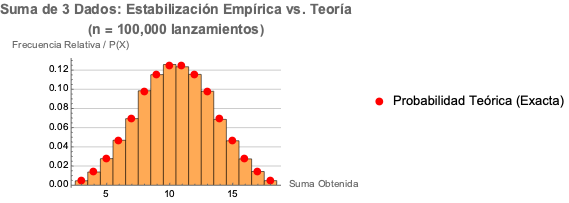

In [18]:
(* 1. Definición del tamaño de la muestra *)
n = 100000;

(* 2. Simulación: Generar n tríos de dados y sumarlos *)
(* Cada fila representa un lanzamiento de 3 dados, Total suma las filas *)
sumas3Dados = Total[RandomInteger[{1, 6}, {n, 3}], {2}];

(* 3. Modelo Teórico: Distribución de la suma de 3 variables uniformes discretas *)
distTeorica = TransformedDistribution[x + y + z, 
    {x \[Distributed] DiscreteUniformDistribution[{1, 6}], 
     y \[Distributed] DiscreteUniformDistribution[{1, 6}], 
     z \[Distributed] DiscreteUniformDistribution[{1, 6}]}];

(* Calcular los valores de probabilidad teórica para el rango 3 a 18 *)
puntosTeoricos = Table[{s, PDF[distTeorica, s]}, {s, 3, 18}];

(* 4. Visualización Compuesta: Histograma Empírico + Puntos Teóricos *)
Show[
 Histogram[sumas3Dados, {2.5, 18.5, 1}, "Probability", 
  ChartStyle -> EdgeForm[Black], 
  ChartBaseStyle -> Lighter[Orange],
  PlotLabel -> Style["Suma de 3 Dados: Estabilización Empírica vs. Teoría\n(n = 100,000 lanzamientos)", Bold, 14],
  AxesLabel -> {"Suma Obtenida", "Frecuencia Relativa / P(X)"},
  GridLines -> {None, Automatic}],
 
 (* Superposición de la probabilidad exacta calculada matemáticamente *)
 ListPlot[puntosTeoricos, 
  PlotStyle -> {Red, PointSize[0.015]}, 
  PlotMarkers -> {"\[FilledCircle]", 12}, 
  PlotLegends -> {"Probabilidad Teórica (Exacta)"}]
]

Legended[-Graphics-, Placed[PointLegend[{Directive[AbsoluteThickness[1.6], 
 
>       RGBColor[1, 0, 0], PointSize[Large]]}, {Probabilidad Teórica Exacta}, 
 
>     LegendMarkers -> {{●, 12}}, Joined -> {False}, LabelStyle -> {}, 
 
>     LegendLayout -> Column], After, Identity]]
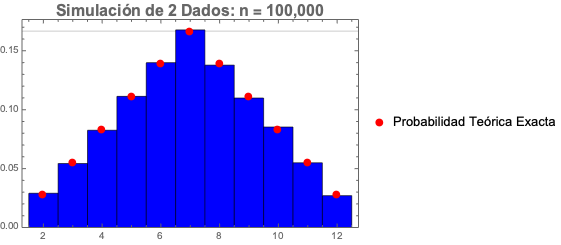

In [29]:
(* 1. Configuración de la simulación *)
n = 100000;

(* 2. Generación de datos aleatorios (Simulación) *)
(* Se generan 100,000 pares de enteros entre 1 y 6 y se suman por fila *)
datosSimulados = Total[RandomInteger[{1, 6}, {n, 2}], {2}];

(* 3. Cálculo del modelo teórico (Exhaustivo) *)
(* Basado en el ejemplo In[2] de la fuente: Flatten[Table[i + j, {i, 6}, {j, 6}]] *)
espacioMuestral = Flatten[Table[i + j, {i, 6}, {j, 6}]];
distTeorica = EmpiricalDistribution[espacioMuestral];

(* 4. Visualización y Documentación *)
Show[
 (* Histograma de los datos simulados con normalización de probabilidad *)
 Histogram[datosSimulados, {1.5, 12.5, 1}, "Probability", 
  ChartStyle -> EdgeForm[Black], 
  ChartBaseStyle -> Blue,
  PlotLabel -> Style["Simulación de 2 Dados: n = 100,000", Bold, 16],
  AxesLabel -> {"Suma obtenida", "Frecuencia Relativa / P(X)"},
  Frame -> True,
  GridLines -> {None, {1/6}}],
 
 (* Superposición de los puntos teóricos exactos *)
 ListPlot[
  Table[{s, PDF[distTeorica, s]}, {s, 2, 12}], 
  PlotStyle -> {Red, PointSize[Large]}, 
  PlotMarkers -> {"\[FilledCircle]", 12},
  PlotLegends -> {"Probabilidad Teórica Exacta"}]
]

In [ ]:


(* Función para simular el experimento y generar el gráfico *)
simulacionDados[n_] := Module[{dado1, dado2, sumas, counts, probRelativa},
  
  (* 1. Simulación: Generar n lanzamientos para cada dado *)
  dado1 = RandomInteger[{1, 6}, n];
  dado2 = RandomInteger[{1, 6}, n];
  
  (* 2. Calcular la suma de los resultados *)
  sumas = dado1 + dado2;
  
  (* 3. Creación del histograma de probabilidad *)
  (* Se usan bines de tamaño 1 centrados en los enteros del 2 al 12 *)
  Histogram[sumas, {1}, "Probability",
   PlotLabel -> Row[{"Simulación con n = ", n}],
   AxesLabel -> {"Suma", "Frecuencia Relativa"},
   ChartStyle -> "SkyBlue",
   ChartLabels -> Range[4, 5],
   TargetUnits -> None,
   PlotRange -> {{1.5, 12.5}, {0, 0.2}},
   GridLines -> {None, {1/6}} (* Línea guía en la probabilidad teórica de la suma 7 *)
  ]
]

(* Generar y mostrar todos los gráficos en una columna *)
Column[simulacionDados /@ ns]

Histogram::hbins: The bin specification Quantity[{1}, None] cannot be used to determine either how many or which bins to use.

Histogram::hspec: The height specification Probability is not one of the named height functions or a function that can be used to compute the heights for each bin.

Histogram::hbins: The bin specification Quantity[{1}, None] cannot be used to determine either how many or which bins to use.

Histogram::hspec: The height specification Probability is not one of the named height functions or a function that can be used to compute the heights for each bin.

Histogram::hbins: The bin specification Quantity[{1}, None] cannot be used to determine either how many or which bins to use.

General::stop: Further output of Histogram::hbins will be suppressed during this calculation.

Histogram::hspec: The height specification Probability is not one of the named height functions or a function that can be used to compute the heights for each bin.

General::stop: Further output of Histogram::hspec will be suppressed during this calculation.